# **Comparison of Gliner2 models performance 📊**

[GLiNER2](https://github.com/fastino-ai/GLiNER2) unifies Named Entity Recognition, Text Classification, Structured Data Extraction, and Relation Extraction into a 205M (base)/ 340M (large) parameter model. It provides efficient CPU-based inference without requiring complex pipelines or external API dependencies.

- See Documentation: https://github.com/fastino-ai/GLiNER2
- See Preprint: https://arxiv.org/html/2507.18546v1
  

## **Definitions**

- true positives (TP) = number of entities of the ground truth found by the model
- false positives (FP) = number of entities not in the ground truth found by the model
- false negatives (FN) = number of entities of the ground truth not found by the model

$$
{\rm precision} = \frac{TP}{TP + FP}
$$

$$
{\rm recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \frac{ {\rm precision} \times {\rm recall} }{ {\rm precision}+{\rm recall} } = \frac{ 2 TP }{ 2TP + FP + FN }
$$


$$
F_{\beta} = \frac{ (1 + \beta^2) \times {\rm precision} \times {\rm recall} }{ (\beta^2 \times {\rm precision}) + {\rm recall} } = \frac{ (1 + \beta^2) \times TP }{ \beta^2 \times (TP + FN) + TP + FP }
$$

In the case of Named Entity Recognition, we focus more on precision than recall. We want the model to make no mistakes rather that identify all entities.

## **Setup**

In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd

from mdner_llm.utils.plot_evaluation_metrics import (
    make_plot_compare_scores_gliner_models,
)

pd.__version__

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.2.3'

## **Load data**

In [4]:
# Define the folder path
# where the evaluation stats are stored for the different GLiNER2 models
base_path = Path("../../results/gliner/evaluation_stats")
# Define the file paths for the different models
file_paths = [
    base_path / "overall_metrics_gliner2-finetuned-large_20260402.xlsx",
    base_path / "overall_metrics_gliner2-base-large_20260402.xlsx",
    base_path / "overall_metrics_gliner2-finetuned-small_20260402.xlsx",
    base_path / "overall_metrics_gliner2-base-small_20260402.xlsx",
]
# Load the data from the Excel files
dfs = [pd.read_excel(path) for path in file_paths]
# Concatenate the dataframes into a single dataframe
scores_for_all_models = pd.concat(dfs, ignore_index=True)
model_names = scores_for_all_models["model_name"].unique()
print(
    f"Loaded evaluation results for {len(dfs)} gliner models: {', '.join(model_names)}"
)
labels = scores_for_all_models["label"].unique()
print(f"Labels: {', '.join(labels)}")
scores_for_all_models

Loaded evaluation results for 4 gliner models: gliner2-finetuned-large, gliner2-base-large, gliner2-finetuned-small, gliner2-base-small
Labels: FFM, MOL, SOFTNAME, SOFTVERS, STIME, TEMP, OVERALL


,model_name,label,nb_of_texts_with_label,pct_is_format_valid,pct_has_no_hallucination,true_positives,false_positives,false_negatives,precision_score,recall_score,f1_score,fbeta_0.5_score
0,gliner2-finetuned-large,FFM,20,100,100,33,10,14,0.767442,0.702128,0.733333,0.753425
1,gliner2-finetuned-large,MOL,20,100,100,65,38,37,0.631068,0.637255,0.634146,0.632296
2,gliner2-finetuned-large,SOFTNAME,17,100,100,21,4,3,0.840000,0.875000,0.857143,0.846774
3,gliner2-finetuned-large,SOFTVERS,11,100,100,12,0,1,1.000000,0.923077,0.960000,0.983607
4,gliner2-finetuned-large,STIME,16,100,100,19,6,3,0.760000,0.863636,0.808511,0.778689
5,gliner2-finetuned-large,TEMP,12,100,100,15,0,1,1.000000,0.937500,0.967742,0.986842
6,gliner2-finetuned-large,OVERALL,23,100,100,165,58,59,0.739910,0.736607,0.738255,0.739247
7,gliner2-base-large,FFM,20,100,100,21,13,26,0.617647,0.446809,0.518519,0.573770
8,gliner2-base-large,MOL,20,100,100,49,40,53,0.550562,0.480392,0.513089,0.534934
9,gliner2-base-large,SOFTNAME,17,100,100,17,4,7,0.809524,0.708333,0.755556,0.787037


## **Plot comparison of metrics by labels and by models**

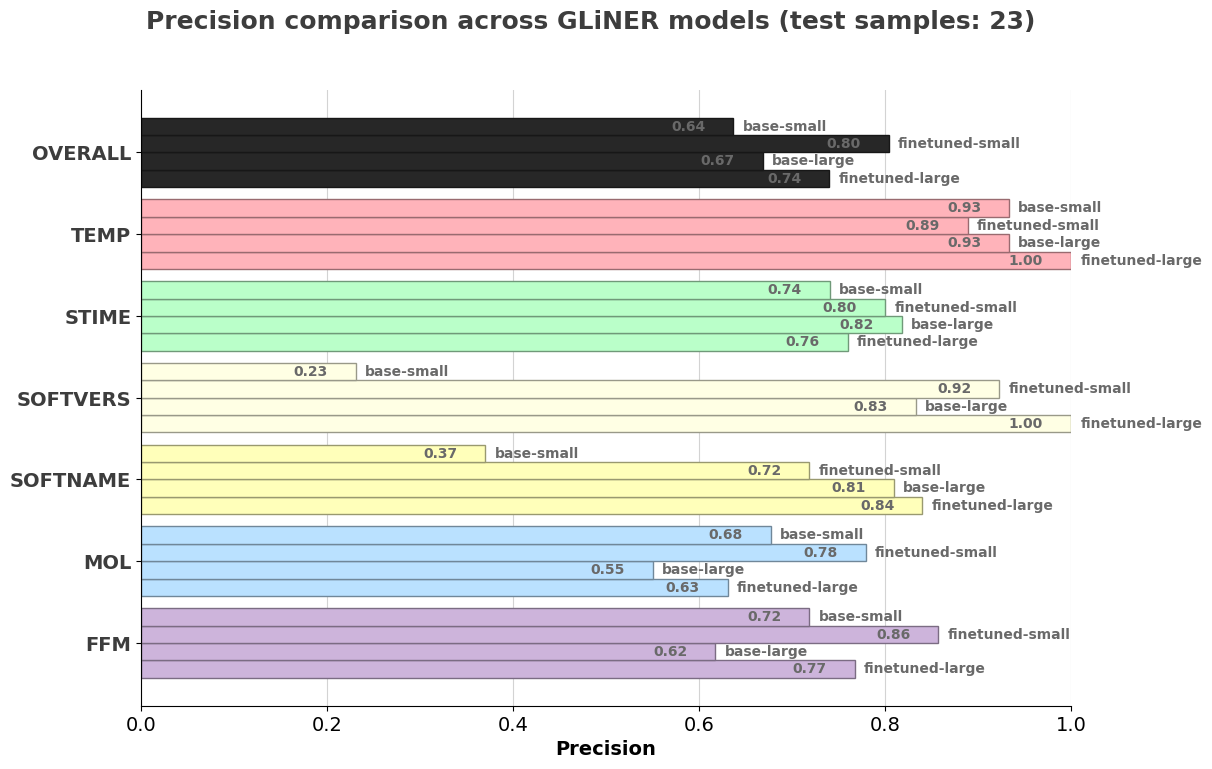

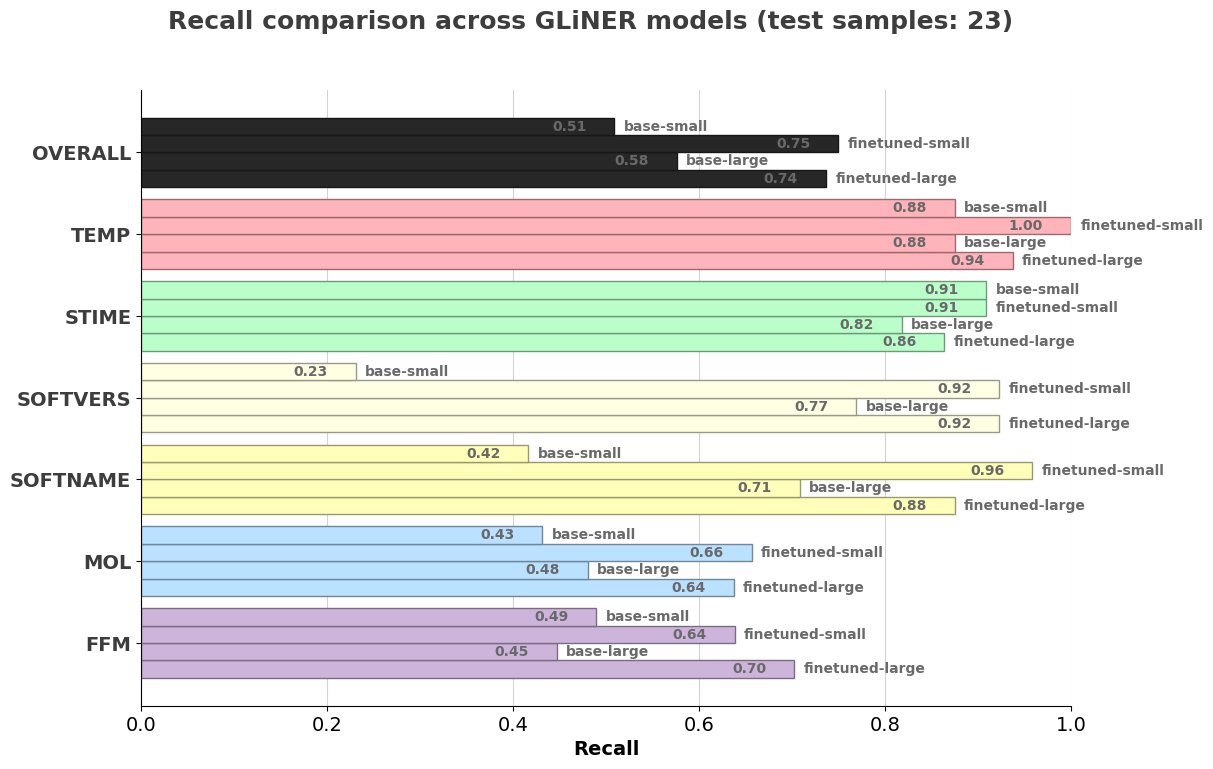

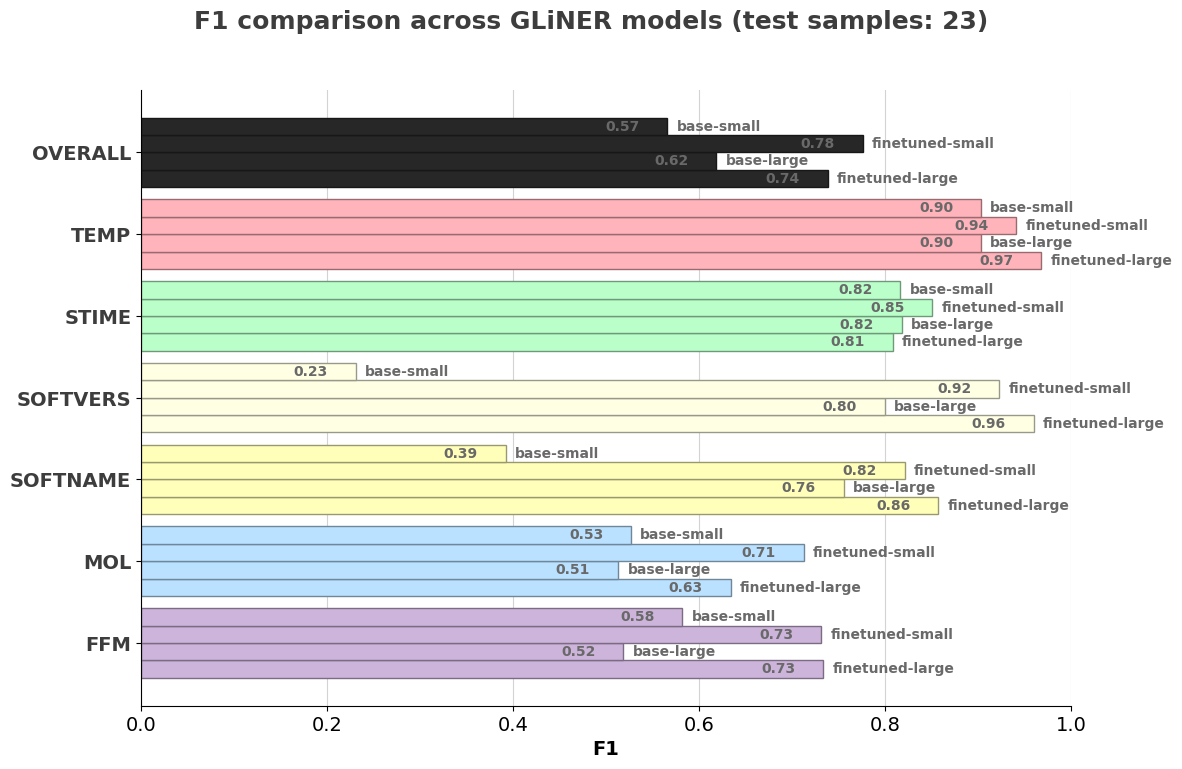

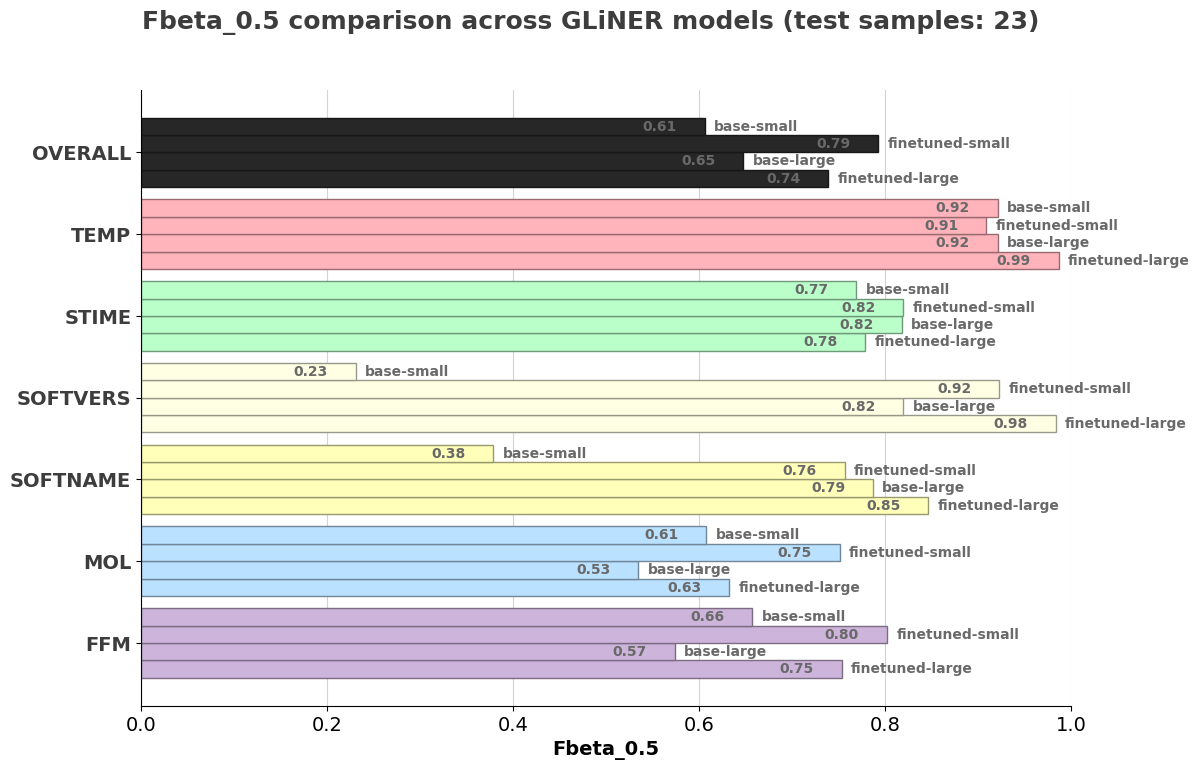

In [5]:
make_plot_compare_scores_gliner_models(scores_for_all_models)